In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import detrend
from statsmodels.tsa.seasonal import seasonal_decompose, STL

from scipy.fft import fft, fftfreq
import pywt

In [17]:
df = pd.read_csv('retail_sales_mock_data.csv')

In [18]:
df.head(5)

,Date,SalesAmount,Promotion,HolidayMonth
0,2020-01-01,12248,0,0
1,2020-02-01,13011,0,0
2,2020-03-01,12722,0,0
3,2020-04-01,14030,1,0
4,2020-05-01,7783,0,0


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Date          48 non-null     object
 1   SalesAmount   48 non-null     int64 
 2   Promotion     48 non-null     int64 
 3   HolidayMonth  48 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 1.6+ KB


In [49]:
# пропусков нет

# Разведочный анализ данных (EDA)

Провести предварительный анализ временного ряда, визуализации различных типов.

In [ ]:
# Преобразуем дату
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

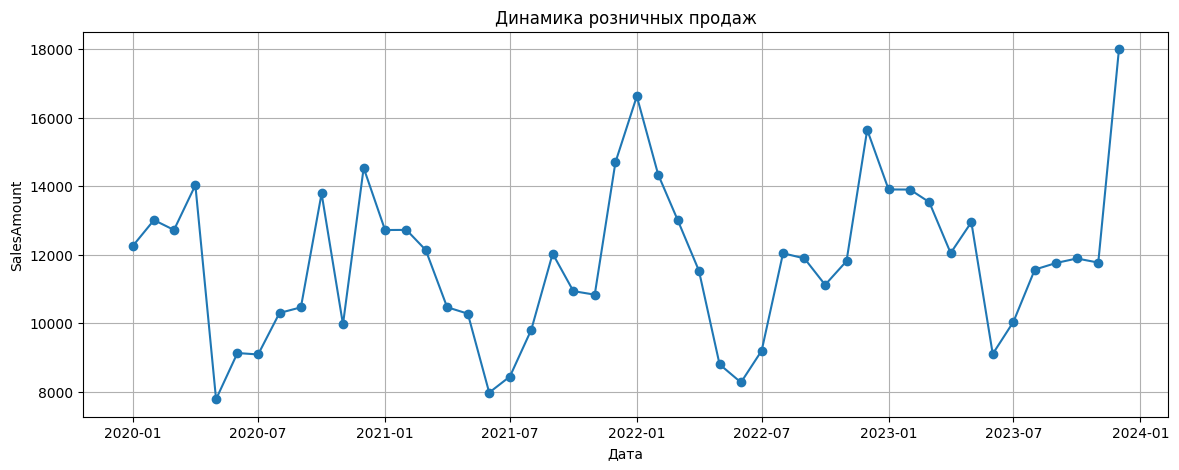

In [23]:
plt.figure(figsize=(14,5))
plt.plot(df['SalesAmount'], marker='o')
plt.title("Динамика розничных продаж")
plt.xlabel("Дата")
plt.ylabel("SalesAmount")
plt.grid(True)
plt.show()

In [ ]:
# Каждый год есть заметные всплески продаж на новогодние праздники и сильный спад к середине лета. Прослеживается явная периодичность. Возможен небольшой восходящий тренд

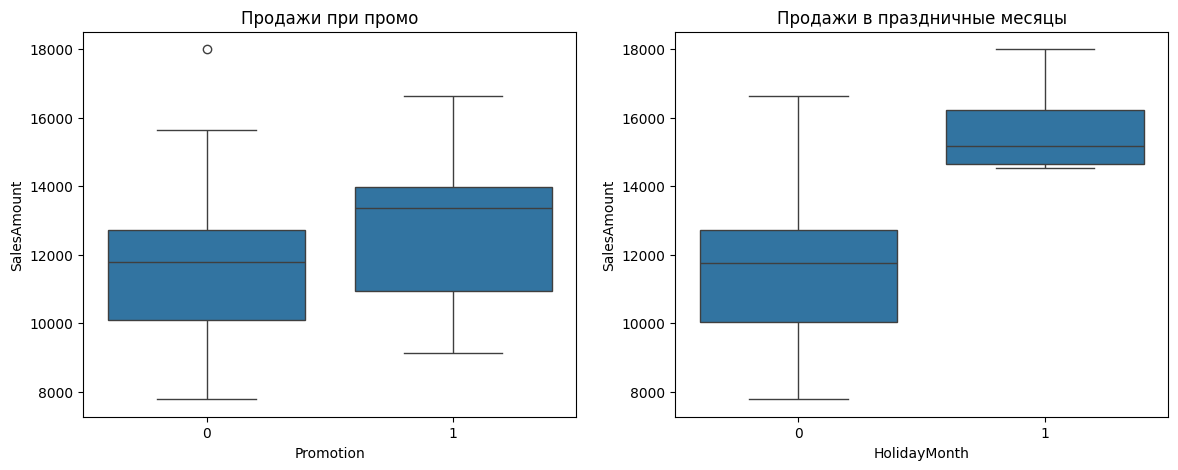

In [24]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.boxplot(x='Promotion', y='SalesAmount', data=df, ax=axes[0])
axes[0].set_title("Продажи при промо")

sns.boxplot(x='HolidayMonth', y='SalesAmount', data=df, ax=axes[1])
axes[1].set_title("Продажи в праздничные месяцы")

plt.show()

In [ ]:
# Продажи в праздники сильно выше и стабильнее, чем в не праздничные дни.
# Акции тоже увеличивают количество продаж, но, возможно, большаяя часть акций в праздничные дни

In [ ]:
len(df.query('Promotion == 1 and HolidayMonth == 1'))

0

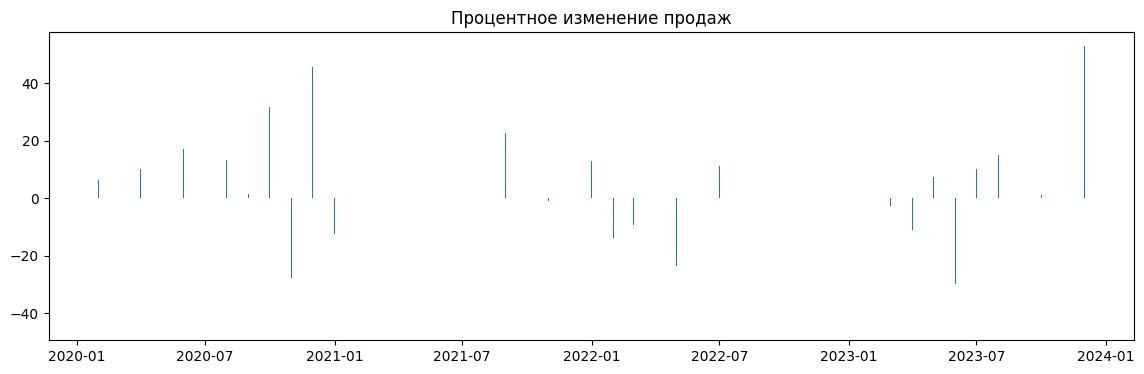

In [38]:
df['pct_change'] = df['SalesAmount'].pct_change() * 100

plt.figure(figsize=(14,4))
plt.bar(df.index, df['pct_change'])
plt.title("Процентное изменение продаж")
plt.show()

Выполнить декомпозицию ряда на компоненты тремя методами:
- классическая аддитивная/мультипликативная/stl декомпозиция (например, seasonal_decompose из statsmodels);
- спектральный анализ с применением быстрого преобразования Фурье (FFT);
- вейвлет-анализ (например, с использованием вейвлета Морле или Добеши).


In [39]:
period = 12

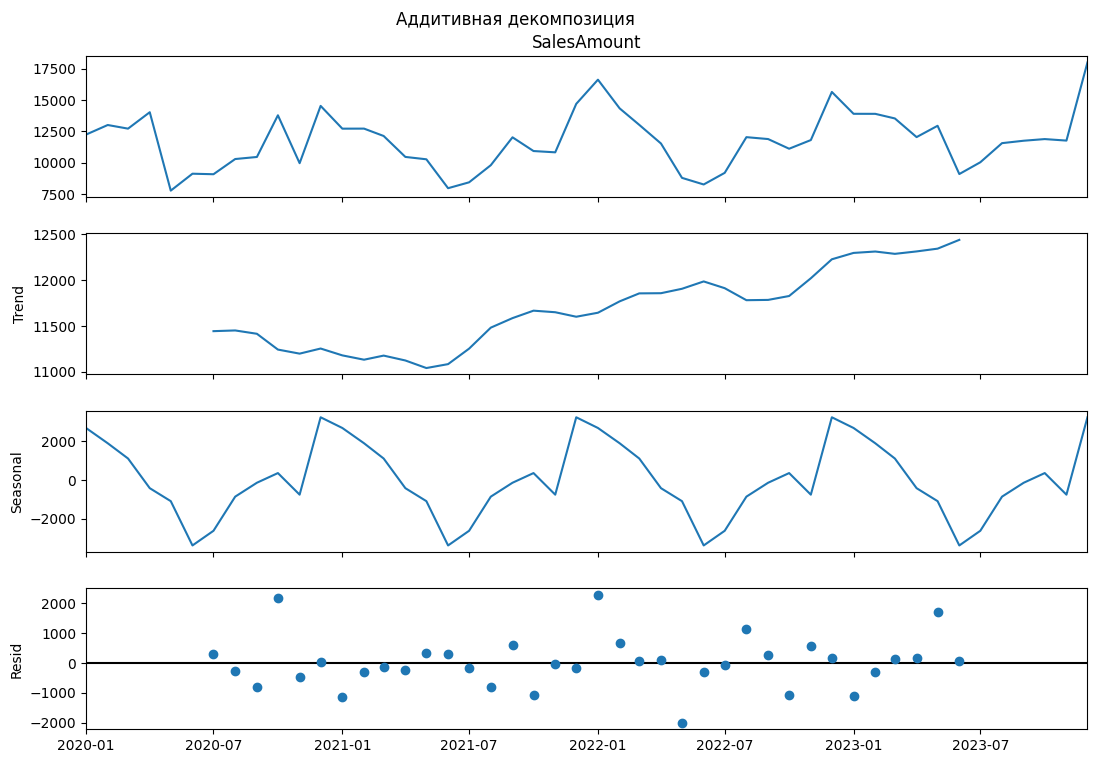

In [40]:
result_add = seasonal_decompose(df['SalesAmount'],
                                model='additive',
                                period=12)

fig = result_add.plot()
fig.set_size_inches(12,8)
plt.suptitle("Аддитивная декомпозиция")
plt.show()

In [ ]:
# Видна выраженная сезонность.
# Умеренный восходящий тренд.
# Амплитуда колебаний примерно одинаковая на всем промежутке
# аддитивная модель подходит

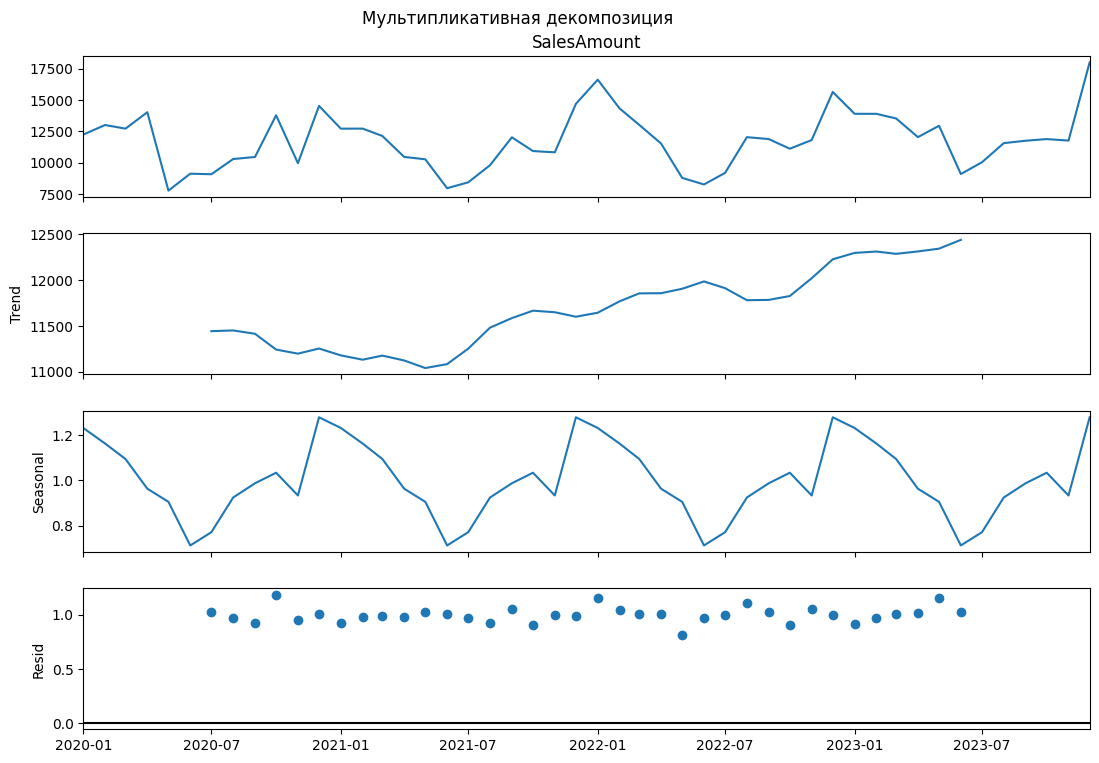

In [41]:
result_mul = seasonal_decompose(df['SalesAmount'],
                                model='multiplicative',
                                period=12)

fig = result_mul.plot()
fig.set_size_inches(12,8)
plt.suptitle("Мультипликативная декомпозиция")
plt.show()

In [ ]:
# Мультипликативная декомпозиция также выявила устойчивый восходящий тренд и выраженную годовую сезонность
# Мультипликативная модель корректно описывает структуру данных, но аддитивная декомпозиция является более интерпретируемой

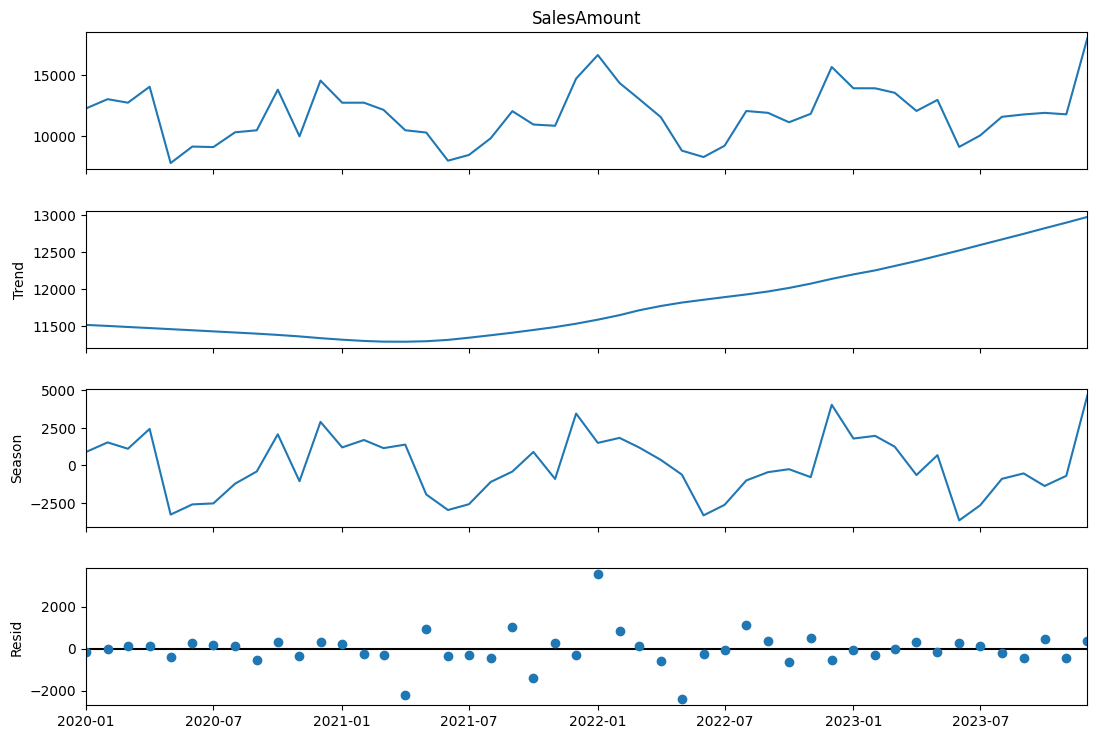

In [42]:
stl = STL(df['SalesAmount'],
          period=12,
          seasonal=13,
          robust=True)

result_stl = stl.fit()

fig = result_stl.plot()
fig.set_size_inches(12,8)
plt.show()

In [43]:
# SLT разложение выявило аналогичные зависимости

In [ ]:
# Необходим убрать тренд, тк с ним плохо работает FFT

sales_detrended = detrend(df['SalesAmount'].values)

n = len(sales_detrended)
fft_vals = fft(sales_detrended)
freqs = fftfreq(n, d=1)

power = np.abs(fft_vals[:n//2])
freqs_pos = freqs[:n//2]

periods = 1 / freqs_pos[freqs_pos > 0]
power_pos = power[freqs_pos > 0]

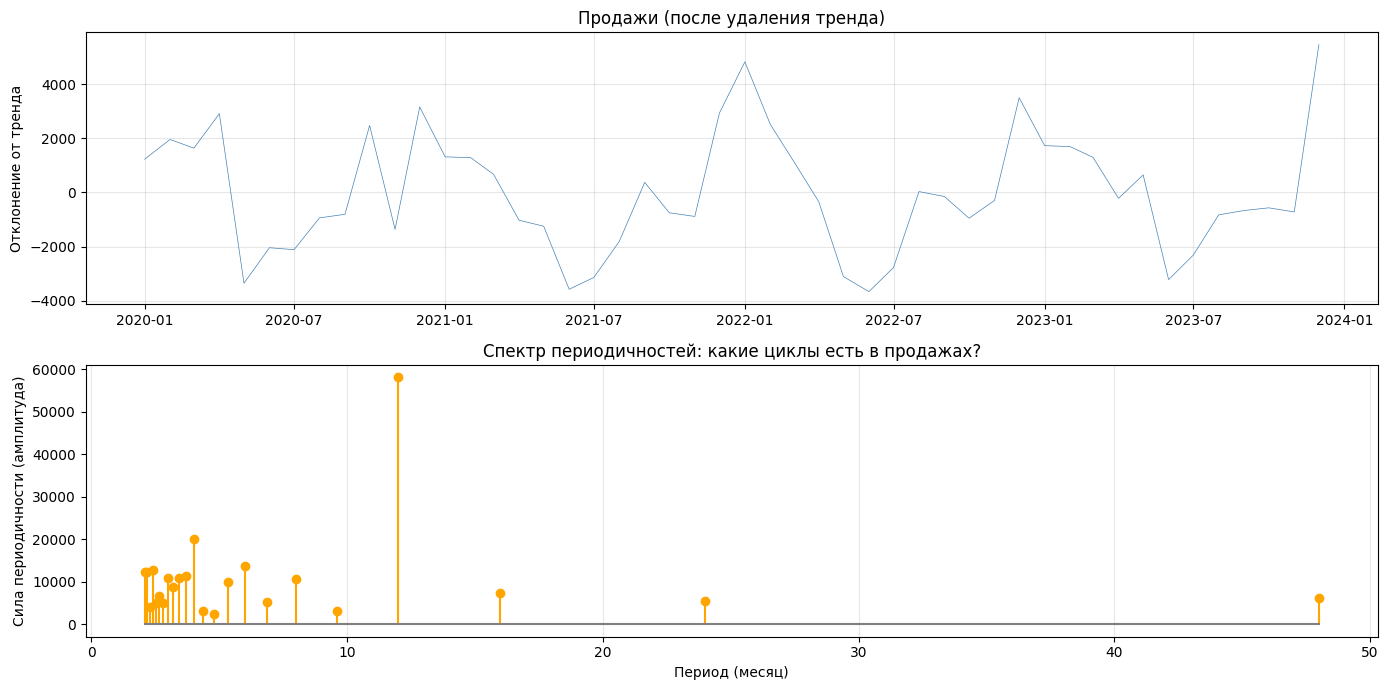

In [51]:
fig, axs = plt.subplots(2, 1, figsize=(14, 7))

# Исходный ряд (после детрендинга)
axs[0].plot(df.index, sales_detrended, color='steelblue', linewidth=0.5)
axs[0].set_title('Продажи (после удаления тренда)')
axs[0].set_ylabel('Отклонение от тренда')
axs[0].grid(True, alpha=0.3)

# Спектр по периодам (удобнее для бизнеса)
mask = (periods >= 2) & (periods <= 700)
axs[1].stem(periods[mask], power_pos[mask], linefmt='orange', markerfmt='o', basefmt='gray')
axs[1].set_xlabel('Период (месяц)')
axs[1].set_ylabel('Сила периодичности (амплитуда)')
axs[1].set_title('Спектр периодичностей: какие циклы есть в продажах?')
axs[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [ ]:
# Спектральный Фурье-анализ выявил доминирующий цикл длительностью около 12 периодов, что соответствует годовой сезонности. 
# Дополнительно обнаружены слабые пики в районе 6 периодов, что может свидетельствовать о наличии полугодовых колебаний. 
# Но явно 12 месяцев

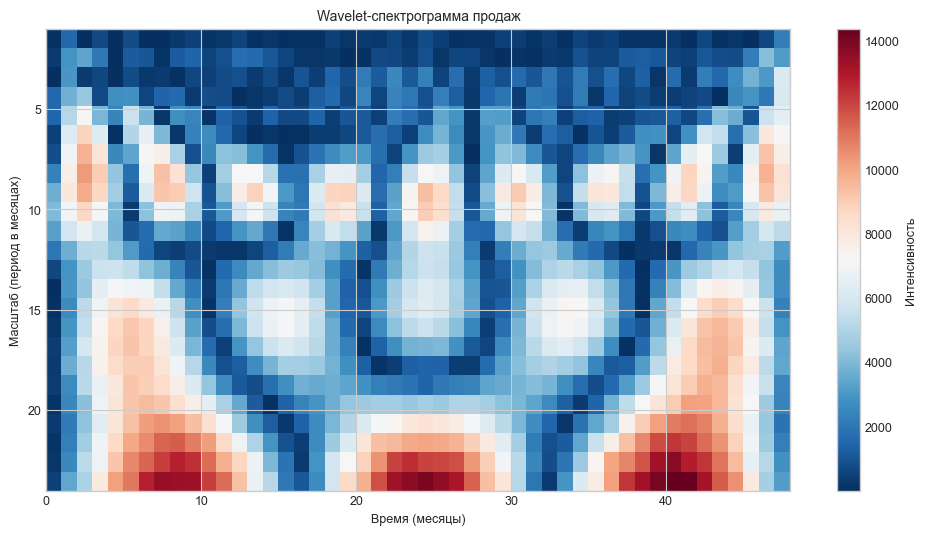

In [61]:
signal = df['SalesAmount'].values

# Масштабы (до 24 месяцев)
scales = np.arange(1, 25)

coefficients, frequencies = pywt.cwt(signal, scales, 'morl')

plt.figure(figsize=(12,6))

plt.imshow(np.abs(coefficients),
           extent=[0, len(signal), scales.max(), scales.min()],
           aspect='auto',
           cmap='RdBu_r')

plt.colorbar(label="Интенсивность")
plt.ylabel("Масштаб (период в месяцах)")
plt.xlabel("Время (месяцы)")
plt.title("Wavelet-спектрограмма продаж")

plt.show()

In [62]:
# В ряду присутствует устойчивая годовая сезонность (период 12 месяцев), которая сохраняется на всем интервале наблюдений
# Амплитуда сезонных колебаний увеличивается во времени. Это свидетельствует о возможном усилении сезонного эффекта в последние годы
# Помимо годовой сезонноси наблюдаются менее выраженные полугодовые колебания, вероятно связанные с промежуточными акциями или сезонными всплесками спроса

Был проанализирован временной ряд розничных продаж. Анализ показал наличие восходящего тренда и выраженной сезонности с периодом около 12 месяцев, а также полугодовую сезонность.

Были применены различные методы разложения и анализа:

**Аддитивная и мультипликативная декомпозиции позволяют разделить ряд на тренд, сезонность и остатки**
- Плюс — простота и наглядность
- Минус — предполагают фиксированную структуру сезонности

**STL-декомпозиция также выделяет тренд и сезонность, но делает это более гибко**
- Плюс — может учитывать изменение сезонности во времени
- Минус — более сложная настройка и интерпретация

**Спектральный анализ (FFT) позволяет определить, какие циклы присутствуют в данных**
- Плюс — хорошо выявляет доминирующие периоды
-  Минус — не показывает, в какие моменты времени эти циклы усиливаются или ослабевают

**Вейвлет-анализ показывает не только наличие циклов, но и их изменение во времени**
- Плюс — подходит для нестационарных рядов
- Минус — сложнее в интерпретации

В целом, для наших учебных данных для выявления сезонности и тренда достаточно просто посмотреть на самый первый график. Данные хорошо читаются и легко интерпретируются с 
точки зрения жизненной логики и бизнеса.
Все наши методы подтвердили наличие годового цикла

# Построение прогнозных моделей

На основе результатов EDA и декомпозиции подобрать параметры моделей ARIMA и SARIMAX.

Обучить модели на тренировочной выборке, выполнить прогноз на максимально возможный горизонт с сохранением приемлемого качества.